In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV


from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load the dataset
file_path = '/content/final_ipl_batsman_prediction_data (1).xlsx'
df = pd.read_excel(file_path)

In [ ]:
df.head()

,name,country,year,team,age,bat_style,ipl_runs,ipl_avg,ipl_sr,ipl_50,ipl_4s,ipl_6s,price
0,aaron finch,australia,2018,punjab-kings,32,right-handed-bat,2091,24.89,128.21,15,214,78,62000000
1,ajinkya rahane,india,2018,rajasthan-royals,30,right-handed-bat,4642,30.14,123.43,30,478,103,40000000
2,apoorv wankhade,india,2018,kolkata-knight-riders,26,right-handed-bat,0,0.00,0.00,0,0,0,2000000
3,aryaman birla,india,2018,rajasthan-royals,21,left-handed-bat,0,0.00,0.00,0,0,0,3000000
4,chris gayle,west indies,2018,punjab-kings,39,left-handed-bat,4965,39.72,148.97,31,405,357,20000000


In [ ]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       188 non-null    object 
 1   country    188 non-null    object 
 2   year       188 non-null    int64  
 3   team       188 non-null    object 
 4   age        188 non-null    int64  
 5   bat_style  188 non-null    object 
 6   ipl_runs   188 non-null    int64  
 7   ipl_avg    188 non-null    float64
 8   ipl_sr     188 non-null    float64
 9   ipl_50     188 non-null    int64  
 10  ipl_4s     188 non-null    int64  
 11  ipl_6s     188 non-null    int64  
 12  price      188 non-null    int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 19.2+ KB


,year,age,ipl_runs,ipl_avg,ipl_sr,ipl_50,ipl_4s,ipl_6s,price
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,1.880000e+02
mean,2020.765957,27.962766,1119.829787,20.179415,107.839255,6.361702,105.888298,42.984043,2.388298e+07
std,2.101314,5.207327,1451.452922,12.149826,50.407794,9.757872,141.432258,57.249382,3.039648e+07
min,2018.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+06
25%,2018.000000,24.750000,32.750000,10.792500,99.937500,0.000000,3.000000,1.000000,2.000000e+06
50%,2022.000000,28.000000,439.000000,22.300000,123.430000,1.000000,39.000000,15.500000,1.000000e+07
75%,2022.000000,31.000000,1706.000000,28.485000,138.610000,9.250000,169.000000,66.750000,3.250000e+07
max,2024.000000,58.000000,6565.000000,48.630000,177.220000,62.000000,664.000000,357.000000,1.600000e+08


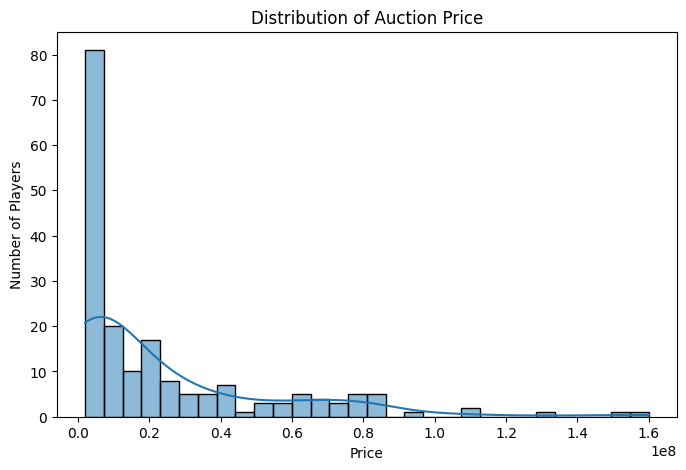

In [ ]:
#1.1 Histogram of price
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of Auction Price")
plt.xlabel("Price")
plt.ylabel("Number of Players")
plt.show()

#Distribution will be right-skewed → most players have low/medium prices,
#but a few stars get very high prices (crores).
#Confirms that auction price has big inequality.

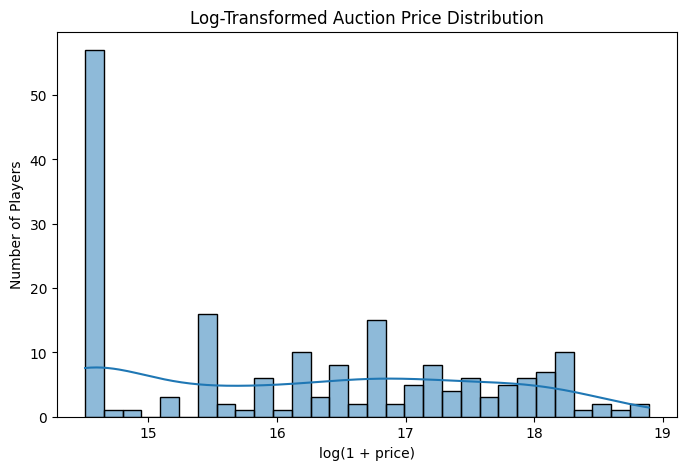

In [ ]:
#1.2 Log-transformed Price (to reduce skewness)
df['log_price'] = np.log1p(df['price'])  # log(1 + price)

plt.figure(figsize=(8,5))
sns.histplot(df['log_price'], bins=30, kde=True)
plt.title("Log-Transformed Auction Price Distribution")
plt.xlabel("log(1 + price)")
plt.ylabel("Number of Players")
plt.show()

#After log transform, distribution becomes more symmetric.
#This is good for regression models → model can learn patterns better.

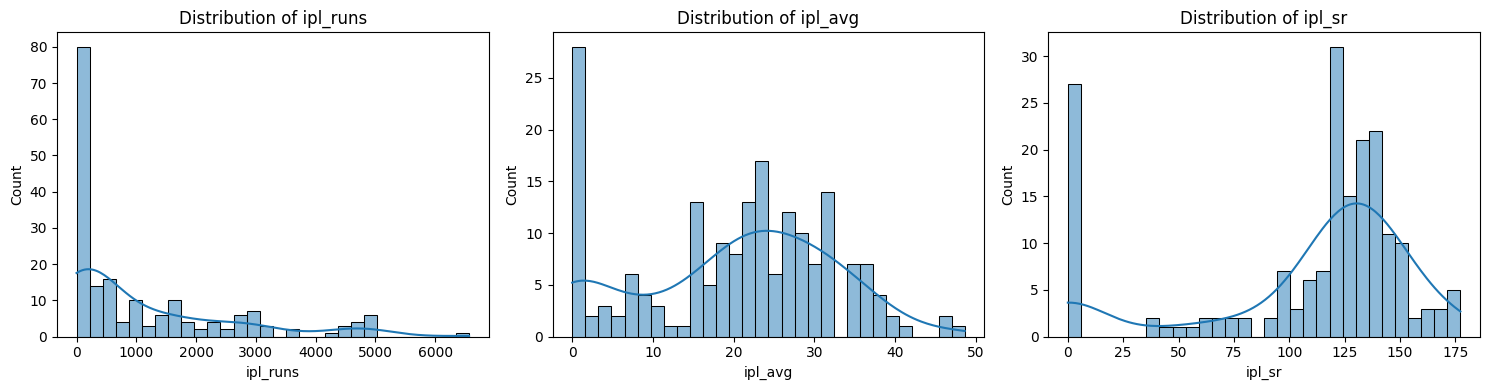

In [ ]:
#2.1 Histogram for ipl_runs, ipl_avg, ipl_sr
num_cols = ['ipl_runs', 'ipl_avg', 'ipl_sr']

plt.figure(figsize=(15,4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

#ipl_runs:
#Many players have low to medium total runs (role players / new players).
#Few players with very high runs → long-career star batters.

#ipl_avg:
#Most batsmen have average between 20–35.
#Very high average (40+) indicates top consistent performers.

#ipl_sr:
#Many around 120–140 (typical IPL strike rate).
#Very high strike rate >160 → finishers / power-hitters

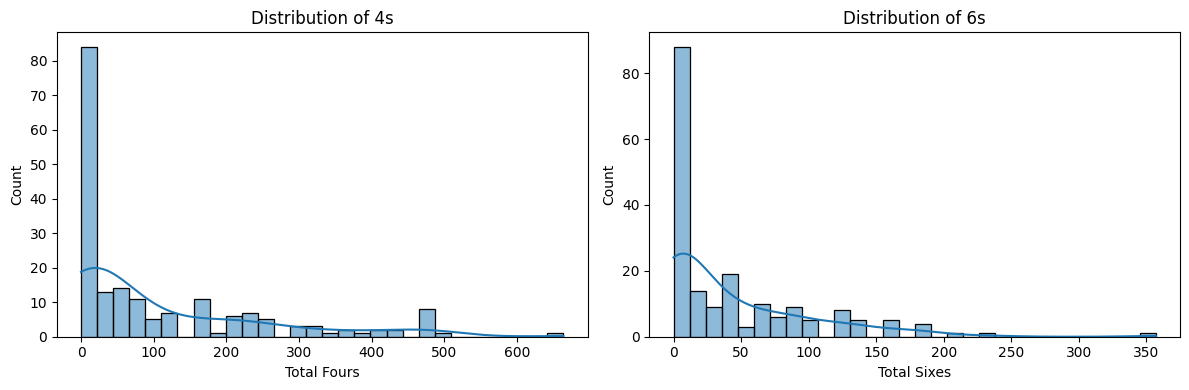

In [ ]:
#2.2 Boundaries – 4s and 6s
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['ipl_4s'], bins=30, kde=True)
plt.title("Distribution of 4s")
plt.xlabel("Total Fours")

plt.subplot(1,2,2)
sns.histplot(df['ipl_6s'], bins=30, kde=True)
plt.title("Distribution of 6s")
plt.xlabel("Total Sixes")

plt.tight_layout()
plt.show()

#Most players have limited boundaries, but a few big names have huge 4s/6s counts.
#High 6s count usually indicates T20 impact players who may get premium prices.


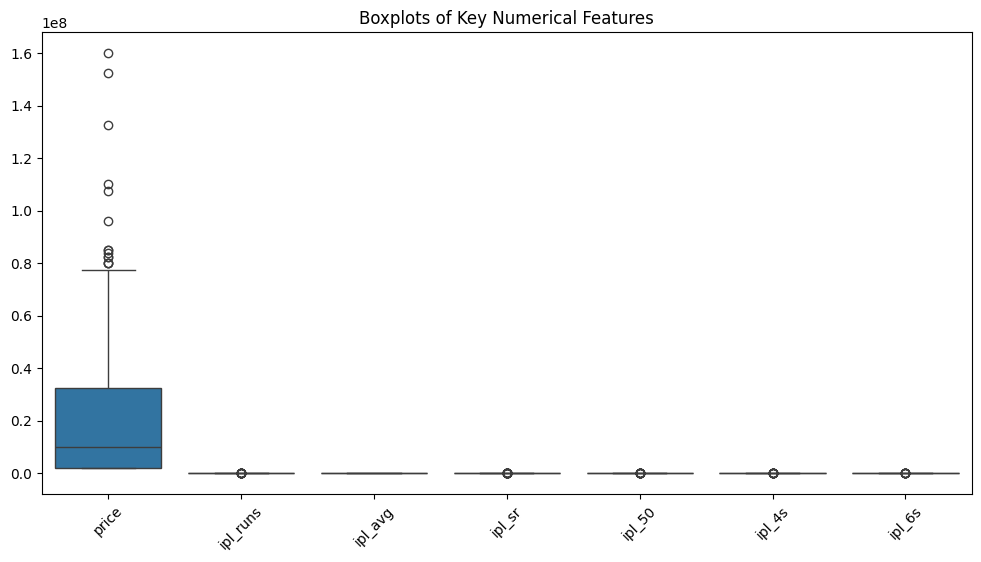

In [ ]:
#3.1 Boxplot for Price & Key Performance Stats
cols = ['price', 'ipl_runs', 'ipl_avg', 'ipl_sr', 'ipl_50', 'ipl_4s', 'ipl_6s']

plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Key Numerical Features")
plt.show()


#Boxplot will show many outliers at upper end (especially for price, ipl_runs, ipl_6s).
#These outliers are usually star players, not errors → don’t blindly remove them.
#Confirms IPL market is dominated by few elite batsmen.


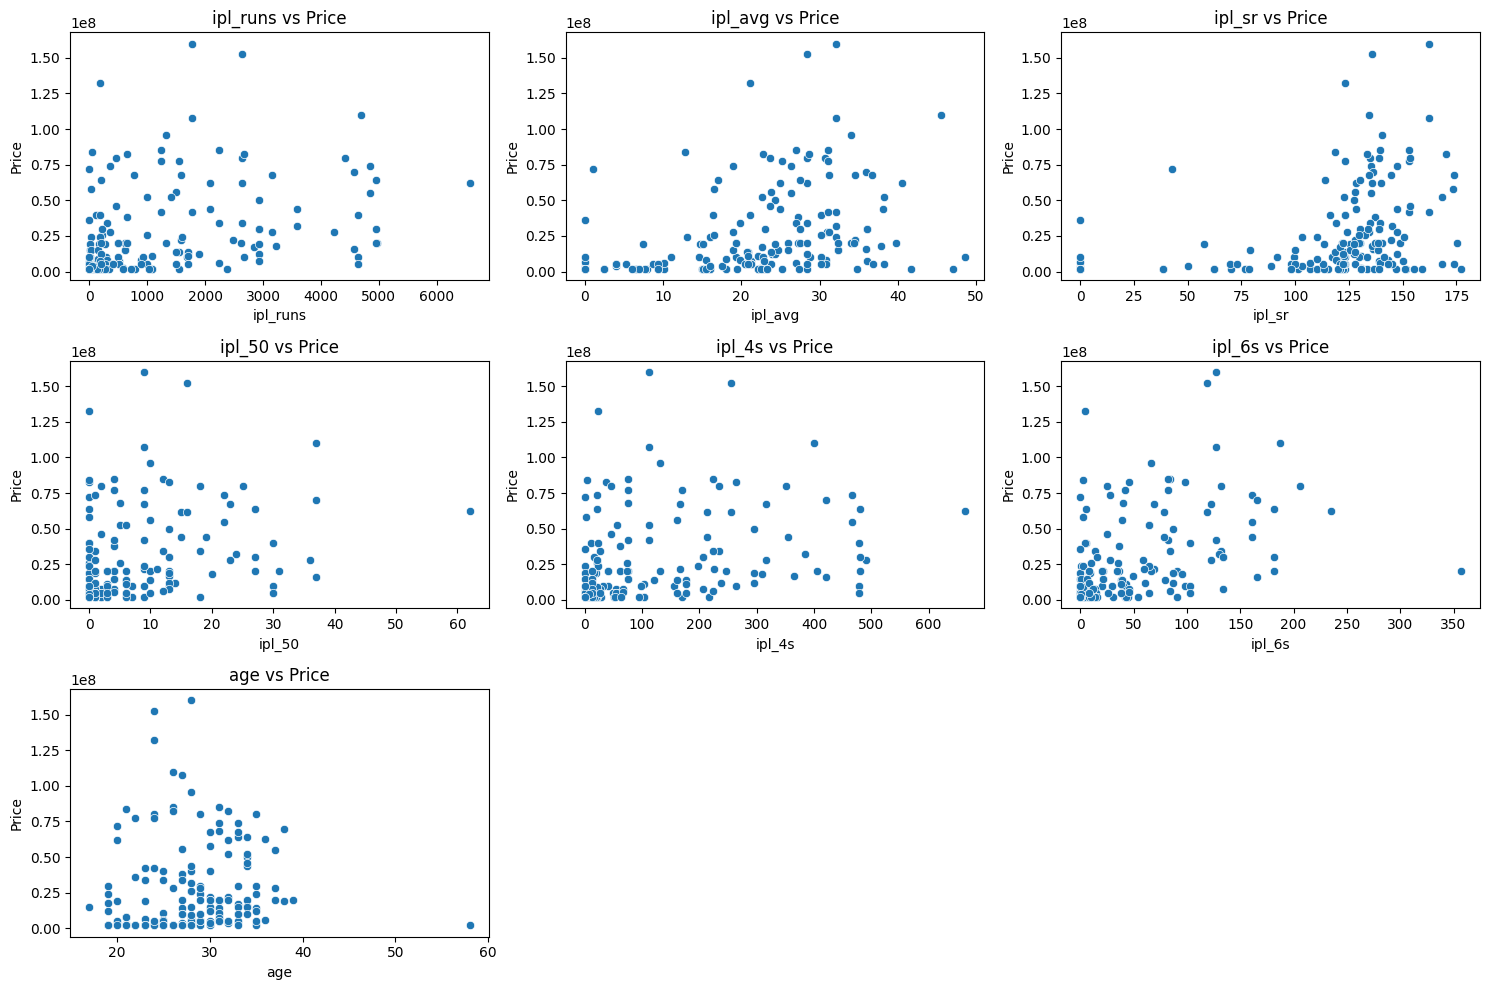

In [ ]:
#4.1 Scatter Plots – Performance vs Price
features_vs_price = ['ipl_runs', 'ipl_avg', 'ipl_sr', 'ipl_50', 'ipl_4s', 'ipl_6s', 'age']

plt.figure(figsize=(15,10))
for i, col in enumerate(features_vs_price, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.title(f"{col} vs Price")
plt.tight_layout()
plt.show()

#ipl_runs vs price:
#Upward trend → players with more total runs usually get higher prices, but not perfectly linear.

#ipl_avg vs price:
#Higher average → more value; but some with medium avg may still be expensive (due to role/strike rate).

#ipl_sr vs price:
#Explosive strike rate can boost price especially for finishers.

#ipl_50, ipl_4s, ipl_6s vs price:
#More 50s/boundaries → more consistent + impactful → higher bids.

#age vs price:
#Very young + very old may have different patterns:
#Mid-20s to early 30s often peak price region.


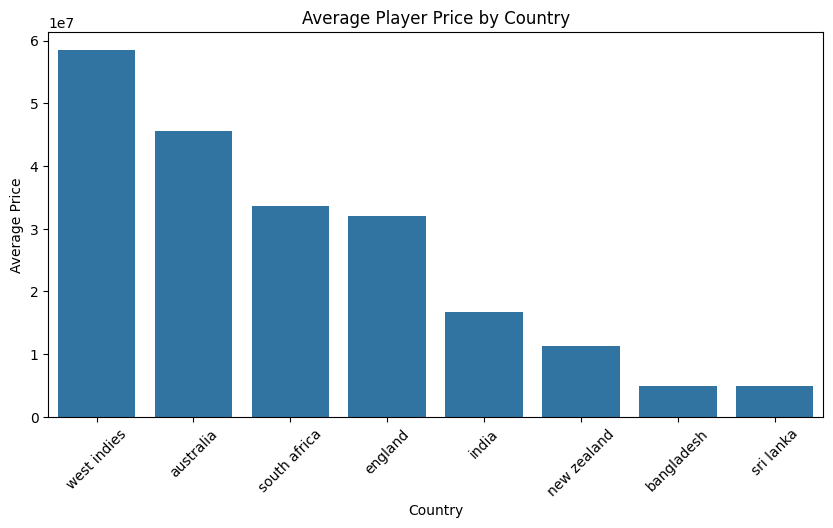

In [ ]:
#6.1 Average Price by Country
plt.figure(figsize=(10,5))
avg_price_country = df.groupby('country')['price'].mean().sort_values(ascending=False)

sns.barplot(x=avg_price_country.index, y=avg_price_country.values)
plt.xticks(rotation=45)
plt.title("Average Player Price by Country")
plt.xlabel("Country")
plt.ylabel("Average Price")
plt.show()

#You’ll likely see:
#Indian players may dominate in count,
#But some foreign countries (e.g., Australia, England, WI) may have higher
#average price because only top-tier overseas batsmen are picked.


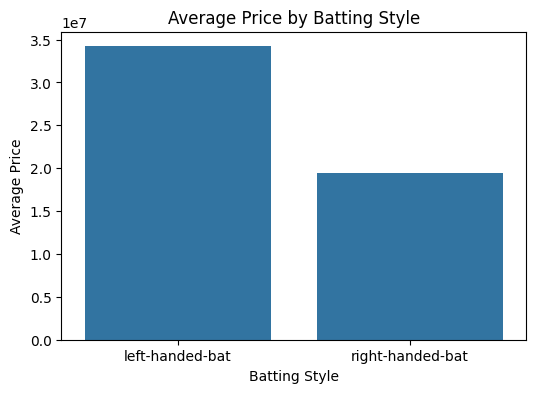

In [ ]:
#6.2 Average Price by Batting Style
plt.figure(figsize=(6,4))
avg_price_bat = df.groupby('bat_style')['price'].mean().sort_values(ascending=False)

sns.barplot(x=avg_price_bat.index, y=avg_price_bat.values)
plt.title("Average Price by Batting Style")
plt.xlabel("Batting Style")
plt.ylabel("Average Price")
plt.show()

#Check if left-handed vs right-handed batsmen show any difference in average price.
#Often difference won’t be huge, but interesting for discussion.

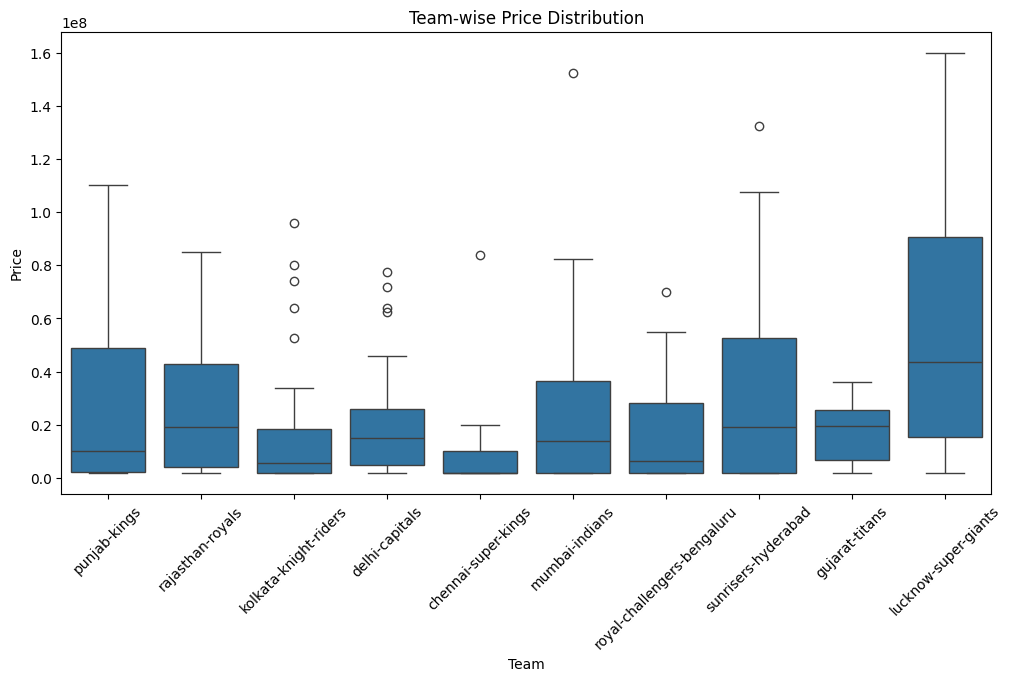

In [ ]:
#6.3 Team-wise Price Distribution
plt.figure(figsize=(12,6))
sns.boxplot(x='team', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Team-wise Price Distribution")
plt.xlabel("Team")
plt.ylabel("Price")
plt.show()

#Some teams may show higher median prices → they spend more on batters.
#Wider spread box = more variation in how that team spends on batsmen.

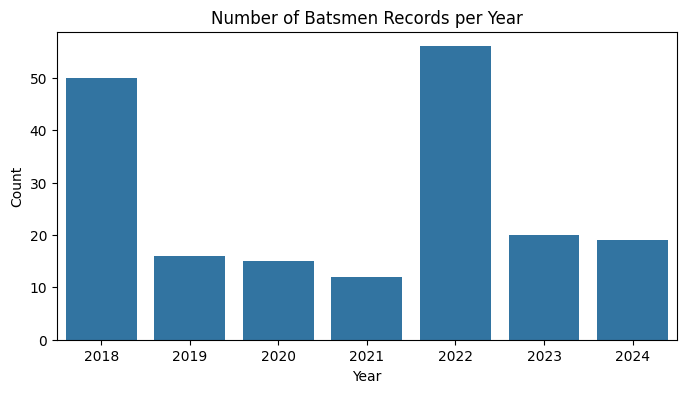

In [ ]:
#7.1 Number of Players per Year
plt.figure(figsize=(8,4))
year_counts = df['year'].value_counts().sort_index()

sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title("Number of Batsmen Records per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

#Shows how many data points you have each year (2018–2025).
#Useful to see if some years are under-represented.

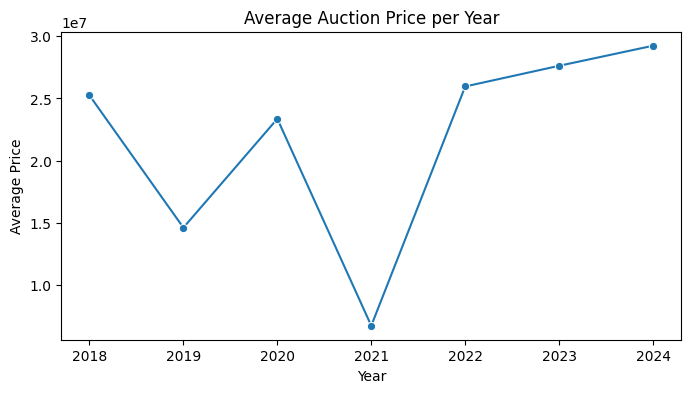

In [ ]:
#7.2 Average Price per Year
plt.figure(figsize=(8,4))
avg_price_year = df.groupby('year')['price'].mean().sort_index()

sns.lineplot(x=avg_price_year.index, y=avg_price_year.values, marker="o")
plt.title("Average Auction Price per Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.show()

#Trend will show if batters’ prices are increasing over the years.
#Upward line → market inflation / increasing purse / demand for batting.

In [ ]:
# Missing values
print(df.isnull().sum())

# Duplicate players (same name & year)
dup = df.duplicated(subset=['name', 'year'])
print("Number of duplicates:", dup.sum())




name         0
country      0
year         0
team         0
age          0
bat_style    0
ipl_runs     0
ipl_avg      0
ipl_sr       0
ipl_50       0
ipl_4s       0
ipl_6s       0
price        0
log_price    0
dtype: int64
Number of duplicates: 0


In [ ]:
#Feature Engineering for IPL Price Prediction
#1. Performance Based Features (Most Important)

df['boundary_rate'] = (df['ipl_4s']*4 + df['ipl_6s']*6) / (df['ipl_runs'] + 1)
df['six_ratio'] = df['ipl_6s'] / (df['ipl_4s'] + df['ipl_6s'] + 1)
df['fifty_rate'] = df['ipl_50'] / (df['ipl_runs'] + 1)
df['runs_per_match'] = df['ipl_runs'] / (df['ipl_50'] + 1)   # modify if match column exists

# Impact Score (tuned formula, adjust weights later)
df['impact_score'] = (df['ipl_avg']*0.4) + (df['ipl_sr']*0.6)

#2. Auction-Based Features
df['price_growth'] = df['price'].pct_change()


#4. Role Encoding (Convert Categorical → Machine Learning readable)
df = pd.get_dummies(df, columns=['bat_style','country','team'], drop_first=True)




In [ ]:
df.head()

,name,year,age,ipl_runs,ipl_avg,ipl_sr,ipl_50,ipl_4s,ipl_6s,price,...,country_west indies,team_delhi-capitals,team_gujarat-titans,team_kolkata-knight-riders,team_lucknow-super-giants,team_mumbai-indians,team_punjab-kings,team_rajasthan-royals,team_royal-challengers-bengaluru,team_sunrisers-hyderabad
0,aaron finch,2018,32,2091,24.89,128.21,15,214,78,62000000,...,False,False,False,False,False,False,True,False,False,False
1,ajinkya rahane,2018,30,4642,30.14,123.43,30,478,103,40000000,...,False,False,False,False,False,False,False,True,False,False
2,apoorv wankhade,2018,26,0,0.00,0.00,0,0,0,2000000,...,False,False,False,True,False,False,False,False,False,False
3,aryaman birla,2018,21,0,0.00,0.00,0,0,0,3000000,...,False,False,False,False,False,False,False,True,False,False
4,chris gayle,2018,39,4965,39.72,148.97,31,405,357,20000000,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [ ]:

# NEW colum for target variable
df['price_2022_target'] = np.where(df['year'] == 2022, df['price'], np.nan)

df['log_price_2022_target'] = df['price_2022_target'].apply(
    lambda x: np.log1p(x) if pd.notnull(x) else np.nan
)


In [ ]:
df['log_price_2022_target'] = df['price_2022_target'].apply(
    lambda x: np.log1p(x) if pd.notnull(x) else np.nan
)


In [ ]:
# Sirf 2022 waale rows jinke target available hain
train_df = df[df['log_price_2022_target'].notna()].copy()


# Use feature engineering columns + original performance stats
feature_cols = [
    'ipl_runs','ipl_avg','ipl_sr','ipl_4s','ipl_6s','ipl_50',
    'boundary_rate','six_ratio','impact_score',
    'age', 'fifty_rate', 'price_growth'
]


X = train_df[feature_cols]
y = train_df['log_price_2022_target']

print("NaN in target y:", y.isna().sum())  # should be 0



NaN in target y: 0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
X_train.head()

,ipl_runs,ipl_avg,ipl_sr,ipl_4s,ipl_6s,ipl_50,boundary_rate,six_ratio,impact_score,age,fifty_rate,price_growth
127,2636,28.34,135.05,234,132,18,0.655290,0.359673,92.366,29,0.006826,-0.255814
123,1706,20.80,122.92,176,38,6,0.545987,0.176744,82.072,31,0.003515,4.500000
101,0,0.00,0.00,0,0,0,0.000000,0.000000,0.000,27,0.000000,0.000000
110,347,23.13,151.53,29,16,2,0.609195,0.347826,100.170,21,0.005747,-0.933333
99,318,19.88,119.11,26,14,1,0.589342,0.341463,79.418,23,0.003135,16.000000


In [ ]:
#Random Forest Regressor Base model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_price = np.expm1(y_pred_rf)

print("\n Random Forest Evaluation Results")
print("MAE:", mean_absolute_error(np.expm1(y_test), y_pred_rf_price))
print("RMSE:", np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_rf_price)))
print("R2 Score:", r2_score(np.expm1(y_test), y_pred_rf_price))



 Random Forest Evaluation Results
MAE: 11827900.496058403
RMSE: 15866109.607092097
R2 Score: 0.7750315610477528


          Feature  Importance
11   price_growth    0.345806
1         ipl_avg    0.168906
4          ipl_6s    0.137760
5          ipl_50    0.067491
0        ipl_runs    0.063022
9             age    0.045080
3          ipl_4s    0.038598
6   boundary_rate    0.036053
7       six_ratio    0.032935
10     fifty_rate    0.027623
8    impact_score    0.021889
2          ipl_sr    0.014838


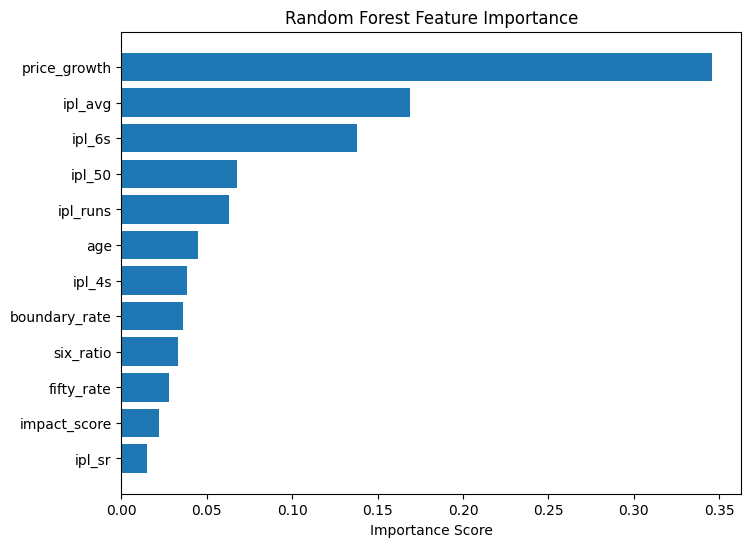

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance)

plt.figure(figsize=(8,6))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Base model
rf = RandomForestRegressor(random_state=42)

# ✅ Fixed hyperparameter search space
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 8, 10, 12, 15],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.8],  # removed 'auto'
    "bootstrap": [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("\nBest RF Params:", rf_random_search.best_params_)

best_rf = rf_random_search.best_estimator_

# Predict & evaluate (assuming y is log-price)
y_pred_rf_log = best_rf.predict(X_test)
y_test_price = np.expm1(y_test)
y_pred_rf_price = np.expm1(y_pred_rf_log)

print("\n Tuned Random Forest Performance (₹ price scale)")
print("MAE :", mean_absolute_error(y_test_price, y_pred_rf_price))
print("RMSE:", np.sqrt(mean_squared_error(y_test_price, y_pred_rf_price)))
print("R2  :", r2_score(y_test_price, y_pred_rf_price))


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 12, 'bootstrap': True}

 Tuned Random Forest Performance (₹ price scale)
MAE : 15413213.239110371
RMSE: 21161958.076208852
R2  : 0.5997858921556991


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Convert log results back to Rupees for Random Forest
y_pred_actual_rf = np.expm1(y_pred_rf_log)   # Predicted ₹ using Random Forest
y_test_actual_rf = np.expm1(y_test)          # Actual ₹

# Get player names for test data using original dataframe index
# change 'name' -> 'Player' / 'player_name' if different
test_players = train_df.loc[y_test.index, 'name']

# Create comparison table
comparison_rf = pd.DataFrame({
    'Player': test_players.values,
    'Actual Price (₹)': y_test_actual_rf.round(0),
    'Predicted Price (₹)': y_pred_actual_rf.round(0)
})

# Display results
print("\nRandom Forest Prediction Comparison (₹)")
print(comparison_rf.head(20))

# Model evaluation in Rupees
mae_rupees_rf = mean_absolute_error(y_test_actual_rf, y_pred_actual_rf)
print(f"\n Mean Absolute Error (Random Forest): ₹{mae_rupees_rf:,.0f}")



Random Forest Prediction Comparison (₹)
                  Player  Actual Price (₹)  Predicted Price (₹)
93        abhijeet tomar         4000000.0            6060405.0
98      anmolpreet singh         2000000.0            5026195.0
126      nicholas pooran       107500000.0           56267626.0
106         david warner        62500000.0           42933938.0
112           evin lewis        20000000.0           15905066.0
143  subhranshu senapati         2000000.0            2021804.0
129      quinton de kock        67500000.0           74587018.0
119       jonny bairstow        67500000.0           57678285.0
137        sai sudharsan         2000000.0           12408107.0
105         david miller        30000000.0           61940975.0
147      wriddhiman saha        19000000.0           38956543.0
96        ajinkya rahane        10000000.0           35742427.0

 Mean Absolute Error (Random Forest): ₹15,413,213
